✓ Forte dei Marmi: 4.833 km of coastline


C:\Users\01and\AppData\Local\Temp\ipykernel_4248\2456141017.py:76: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="lower right", framealpha=0.9)


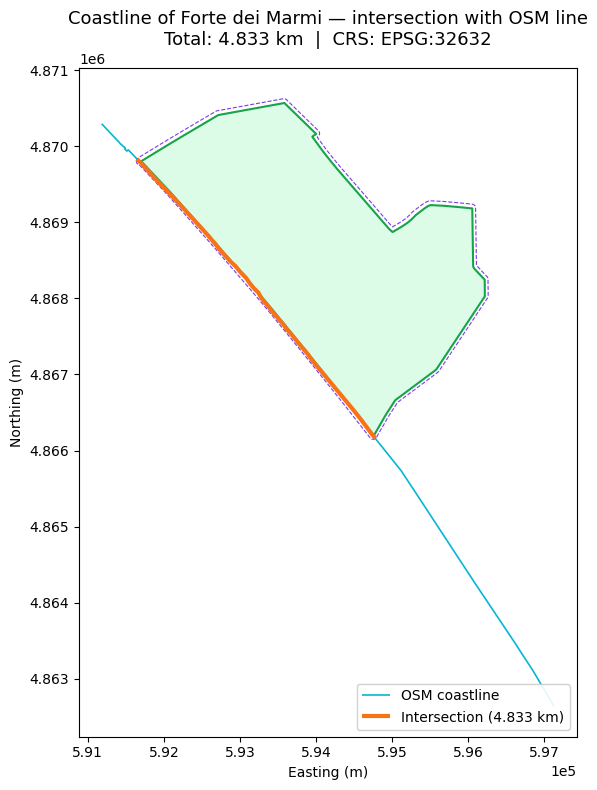

In [14]:
import geopandas as gpd
import matplotlib.pyplot as plt
from src.utils.openstreetmap_manager import (
    OpenStreetMap,
    _extract_lines,
    _normalize_name,
    METRIC_CRS,
    BOUNDARY_BUFFER_METERS,
    MUNICIPALITY_NAME_FIELD,
)

# ── parameters ──────────────────────────────────────────────────────────────────
MUNICIPALITIES_SHP = "data/input/ISTAT/Com01012024_g/Com01012024_g_WGS84.shp"
COASTLINE_GEOJSON  = "data/input/OpenStreetMap/coast_line.geojson"
TARGET_MUNICIPALITY = "Forte dei Marmi"

# ── load data ────────────────────────────────────────────────────────────────
osm = OpenStreetMap()
osm.load_municipalities(MUNICIPALITIES_SHP)  # initializes _municipalities_shp_path; the DataFrame isn't needed here

# The geometry must be read directly from the shapefile and reprojected to a metric CRS
municipalities_gdf = gpd.read_file(MUNICIPALITIES_SHP).to_crs(METRIC_CRS)

mask = municipalities_gdf[MUNICIPALITY_NAME_FIELD].apply(_normalize_name) == _normalize_name(TARGET_MUNICIPALITY)
municipality_row = municipalities_gdf[mask]
assert not municipality_row.empty, f"Municipality '{TARGET_MUNICIPALITY}' not found"

coast = gpd.read_file(COASTLINE_GEOJSON)
if coast.crs is None:
    coast = coast.set_crs("EPSG:4326")
coast = coast.to_crs(METRIC_CRS)
coast["geometry"] = coast.geometry.apply(
    lambda g: g.boundary if g.geom_type in ("Polygon", "MultiPolygon") else g
)
coast = coast[coast.geom_type.isin(["LineString", "MultiLineString"])]

# ── coastline × municipality intersection ────────────────────────────────────────────────
municipality_geom     = municipality_row.geometry.values[0]
municipality_buffered = municipality_geom.buffer(BOUNDARY_BUFFER_METERS)

coast_clip = coast[coast.intersects(municipality_buffered)].copy()
coast_clip["geometry"] = coast_clip.geometry.intersection(municipality_buffered).apply(_extract_lines)
coast_intersection = coast_clip[coast_clip["geometry"].notna()].copy()

total_km = coast_intersection.geometry.length.sum() / 1000
print(f"✓ {TARGET_MUNICIPALITY}: {total_km:.3f} km of coastline")

# ── plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

gpd.GeoSeries([municipality_geom], crs=METRIC_CRS).plot(
    ax=ax, facecolor="#dcfce7", edgecolor="#16a34a",
    linewidth=1.5, zorder=1, label=TARGET_MUNICIPALITY
)
gpd.GeoSeries([municipality_buffered], crs=METRIC_CRS).plot(
    ax=ax, facecolor="none", edgecolor="#7c3aed",
    linewidth=0.8, linestyle="--", zorder=2,
    label=f"Buffer {BOUNDARY_BUFFER_METERS} m"
)
coast[coast.intersects(municipality_buffered.envelope)].plot(
    ax=ax, color="#06b6d4", linewidth=1.2, zorder=3, label="OSM coastline"
)
if not coast_intersection.empty:
    gpd.GeoDataFrame(coast_intersection, crs=METRIC_CRS).plot(
        ax=ax, color="#f97316", linewidth=3, zorder=4,
        label=f"Intersection ({total_km:.3f} km)"
    )

ax.set_title(
    f"Coastline of {TARGET_MUNICIPALITY} — intersection with OSM line\n"
    f"Total: {total_km:.3f} km  |  CRS: {METRIC_CRS}",
    fontsize=13
)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.legend(loc="lower right", framealpha=0.9)
ax.ticklabel_format(style="sci", scilimits=(0, 0), axis="both")
plt.tight_layout()
plt.show()

✓ Caldonazzo: 1.927 km of lake shoreline


C:\Users\01and\AppData\Local\Temp\ipykernel_4248\2428383582.py:74: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="lower right", framealpha=0.9)


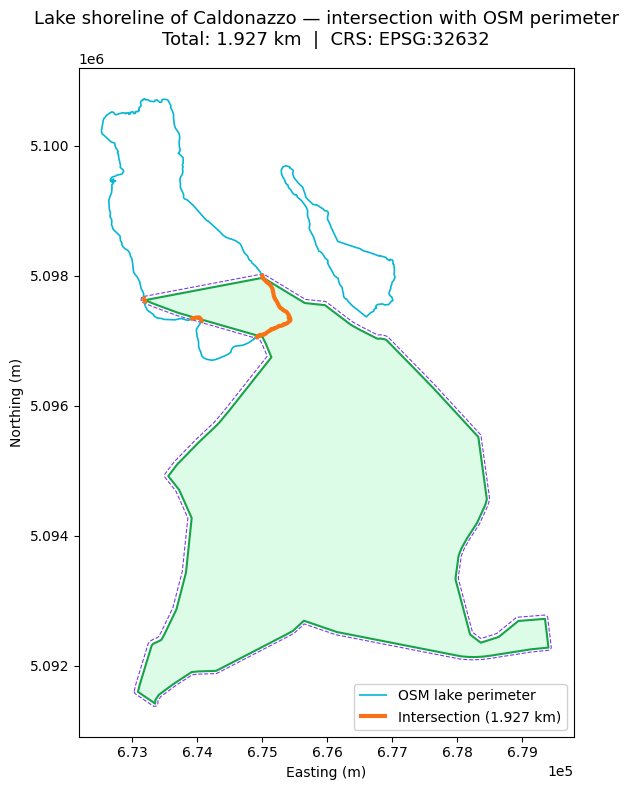

In [15]:
import geopandas as gpd
import matplotlib.pyplot as plt
from src.utils.openstreetmap_manager import (
    OpenStreetMap,
    _extract_lines,
    _normalize_name,
    METRIC_CRS,
    BOUNDARY_BUFFER_METERS,
    MUNICIPALITY_NAME_FIELD,
)

# ── parameters ──────────────────────────────────────────────────────────────────
MUNICIPALITIES_SHP  = "data/input/ISTAT/Com01012024_g/Com01012024_g_WGS84.shp"
LAKE_GEOJSON         = "data/input/OpenStreetMap/lake_coast.geojson"
TARGET_MUNICIPALITY  = "Caldonazzo"

# ── load data ────────────────────────────────────────────────────────────────
osm = OpenStreetMap()
osm.load_municipalities(MUNICIPALITIES_SHP)  # initializes _municipalities_shp_path

municipalities_gdf = gpd.read_file(MUNICIPALITIES_SHP).to_crs(METRIC_CRS)
mask = municipalities_gdf[MUNICIPALITY_NAME_FIELD].apply(_normalize_name) == _normalize_name(TARGET_MUNICIPALITY)
municipality_row = municipalities_gdf[mask]
assert not municipality_row.empty, f"Municipality '{TARGET_MUNICIPALITY}' not found"

lake = gpd.read_file(LAKE_GEOJSON)
if lake.crs is None:
    lake = lake.set_crs("EPSG:4326")
lake = lake.to_crs(METRIC_CRS)
lake["geometry"] = lake.geometry.apply(
    lambda g: g.boundary if g.geom_type in ("Polygon", "MultiPolygon") else g
)
lake = lake[lake.geom_type.isin(["LineString", "MultiLineString"])]

# ── lake × municipality intersection ─────────────────────────────────────────────────
municipality_geom     = municipality_row.geometry.values[0]
municipality_buffered = municipality_geom.buffer(BOUNDARY_BUFFER_METERS)

lake_clip = lake[lake.intersects(municipality_buffered)].copy()
lake_clip["geometry"] = lake_clip.geometry.intersection(municipality_buffered).apply(_extract_lines)
lake_intersection = lake_clip[lake_clip["geometry"].notna()].copy()

total_km = lake_intersection.geometry.length.sum() / 1000
print(f"✓ {TARGET_MUNICIPALITY}: {total_km:.3f} km of lake shoreline")

# ── plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

gpd.GeoSeries([municipality_geom], crs=METRIC_CRS).plot(
    ax=ax, facecolor="#dcfce7", edgecolor="#16a34a",
    linewidth=1.5, zorder=1, label=TARGET_MUNICIPALITY
)
gpd.GeoSeries([municipality_buffered], crs=METRIC_CRS).plot(
    ax=ax, facecolor="none", edgecolor="#7c3aed",
    linewidth=0.8, linestyle="--", zorder=2,
    label=f"Buffer {BOUNDARY_BUFFER_METERS} m"
)
lake[lake.intersects(municipality_buffered.envelope)].plot(
    ax=ax, color="#06b6d4", linewidth=1.2, zorder=3, label="OSM lake perimeter"
)
if not lake_intersection.empty:
    gpd.GeoDataFrame(lake_intersection, crs=METRIC_CRS).plot(
        ax=ax, color="#f97316", linewidth=3, zorder=4,
        label=f"Intersection ({total_km:.3f} km)"
    )

ax.set_title(
    f"Lake shoreline of {TARGET_MUNICIPALITY} — intersection with OSM perimeter\n"
    f"Total: {total_km:.3f} km  |  CRS: {METRIC_CRS}",
    fontsize=13
)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.legend(loc="lower right", framealpha=0.9)
ax.ticklabel_format(style="sci", scilimits=(0, 0), axis="both")
plt.tight_layout()
plt.show()

✓ Asiago: 90.487 km² of protected areas


C:\Users\01and\AppData\Local\Temp\ipykernel_4248\4638040.py:60: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="lower right", framealpha=0.9)
C:\Users\01and\AppData\Local\Temp\ipykernel_4248\4638040.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="lower right", framealpha=0.9)


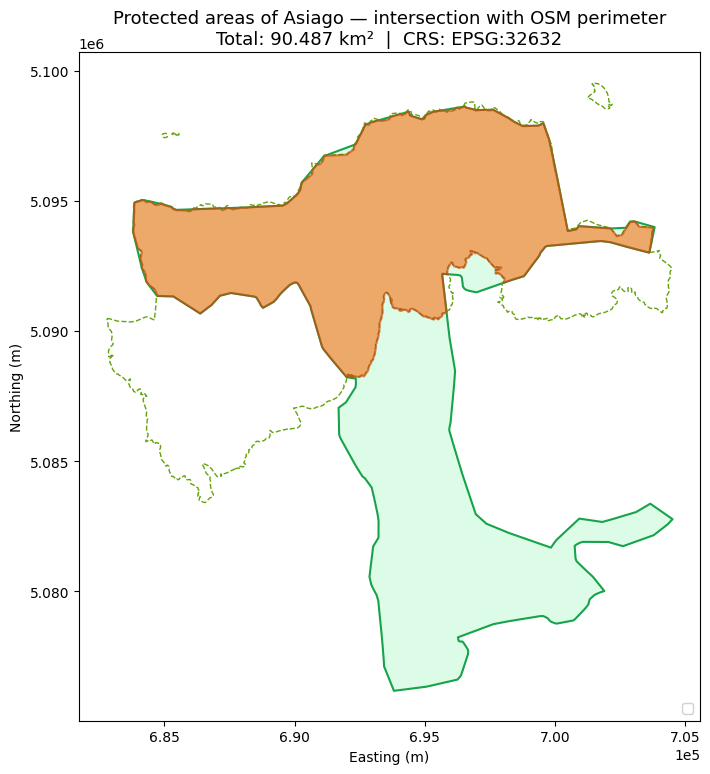

In [11]:
import geopandas as gpd
import matplotlib.pyplot as plt
from src.utils.openstreetmap_manager import (
    OpenStreetMap,
    _normalize_name,
    METRIC_CRS,
    MUNICIPALITY_NAME_FIELD,
)
# ── parameters ──────────────────────────────────────────────────────────────────
MUNICIPALITIES_SHP  = "data/input/ISTAT/Com01012024_g/Com01012024_g_WGS84.shp"
PARKS_GEOJSON        = "data/input/OpenStreetMap/natural_parks.geojson"
TARGET_MUNICIPALITY  = "Asiago"
# ── load data ────────────────────────────────────────────────────────────────
osm = OpenStreetMap()
osm.load_municipalities(MUNICIPALITIES_SHP)  # initializes _municipalities_shp_path
municipalities_gdf = gpd.read_file(MUNICIPALITIES_SHP).to_crs(METRIC_CRS)
mask = municipalities_gdf[MUNICIPALITY_NAME_FIELD].apply(_normalize_name) == _normalize_name(TARGET_MUNICIPALITY)
municipality_row = municipalities_gdf[mask]
assert not municipality_row.empty, f"Municipality '{TARGET_MUNICIPALITY}' not found"
parks = gpd.read_file(PARKS_GEOJSON)
if parks.crs is None:
    parks = parks.set_crs("EPSG:4326")
parks = parks.to_crs(METRIC_CRS)
parks = parks[parks.geometry.notna()]
parks = parks[parks.geom_type.isin(["Polygon", "MultiPolygon"])]
# ── park × municipality intersection (area, not line) ───────────────────────────────
municipality_geom = municipality_row.geometry.values[0]
parks_clip = parks[parks.intersects(municipality_geom)].copy()
parks_clip["geometry"] = parks_clip.geometry.intersection(municipality_geom)
parks_clip["geometry"] = parks_clip.geometry.apply(
    lambda g: g if g.geom_type in ("Polygon", "MultiPolygon") else None
)
parks_intersection = parks_clip[parks_clip["geometry"].notna()].copy()
parks_intersection = parks_intersection[~parks_intersection.geometry.is_empty]
total_sqkm = parks_intersection.geometry.area.sum() / 1_000_000
print(f"✓ {TARGET_MUNICIPALITY}: {total_sqkm:.3f} km² of protected areas")
# ── plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
gpd.GeoSeries([municipality_geom], crs=METRIC_CRS).plot(
    ax=ax, facecolor="#dcfce7", edgecolor="#16a34a",
    linewidth=1.5, zorder=1, label=TARGET_MUNICIPALITY
)
parks[parks.intersects(municipality_geom.envelope)].plot(
    ax=ax, facecolor="none", edgecolor="#65a30d",
    linewidth=1.0, linestyle="--", zorder=2, label="OSM park perimeter"
)
if not parks_intersection.empty:
    gpd.GeoDataFrame(parks_intersection, crs=METRIC_CRS).plot(
        ax=ax, facecolor="#f97316", edgecolor="#c2410c",
        alpha=0.6, linewidth=1.5, zorder=3,
        label=f"Intersection ({total_sqkm:.3f} km²)"
    )
ax.set_title(
    f"Protected areas of {TARGET_MUNICIPALITY} — intersection with OSM perimeter\n"
    f"Total: {total_sqkm:.3f} km²  |  CRS: {METRIC_CRS}",
    fontsize=13
)
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.legend(loc="lower right", framealpha=0.9)
ax.ticklabel_format(style="sci", scilimits=(0, 0), axis="both")
plt.tight_layout()
plt.show()